ЗАГРУЗКА ДАТАСЕТА IMDb
Размер обучающей выборки: 25000
Размер тестовой выборки: 25000

РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

АНАЛИЗ ДЛИН ОТЗЫВОВ
----------------------------------------
Количество отзывов: 50000
Минимальная длина: 7 слов
Максимальная длина: 2494 слов
Средняя длина: 234.76 слов
Медианная длина: 176.00 слов
Стандартное отклонение: 172.91

КВАНТИЛИ ДЛИНЫ ОТЗЫВОВ
----------------------------------------
25% отзывов имеют длину <= 129 слов
50% отзывов имеют длину <= 176 слов
75% отзывов имеют длину <= 285 слов
90% отзывов имеют длину <= 457 слов
95% отзывов имеют длину <= 598 слов
99% отзывов имеют длину <= 914 слов


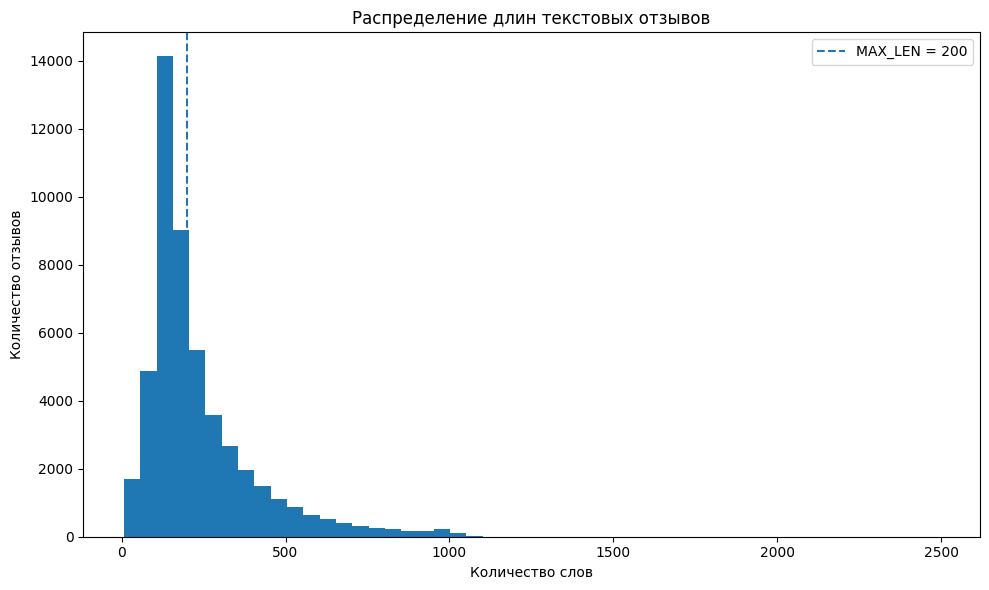


Гистограмма длин отзывов сохранена:
analysis_results/review_lengths_histogram.png


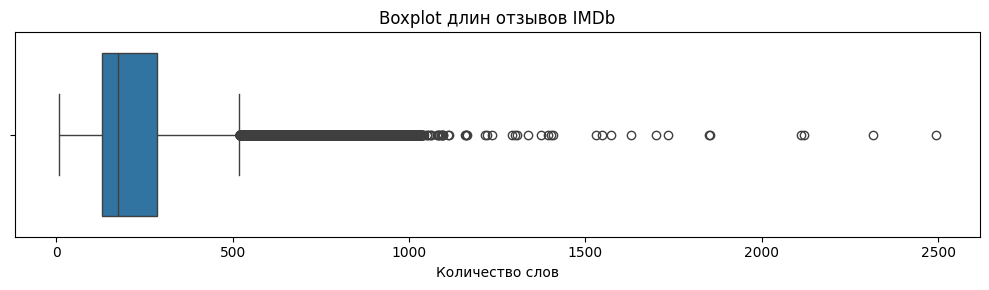


Boxplot длин отзывов сохранён:
analysis_results/review_lengths_boxplot.png

АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ

ОБУЧАЮЩАЯ ВЫБОРКА
----------------------------------------
Положительные отзывы (positive): 12500
Отрицательные отзывы (negative): 12500

ТЕСТОВАЯ ВЫБОРКА
----------------------------------------
Положительные отзывы (positive): 12500
Отрицательные отзывы (negative): 12500

Датасет является сбалансированным.
Выравнивание классов не требуется.


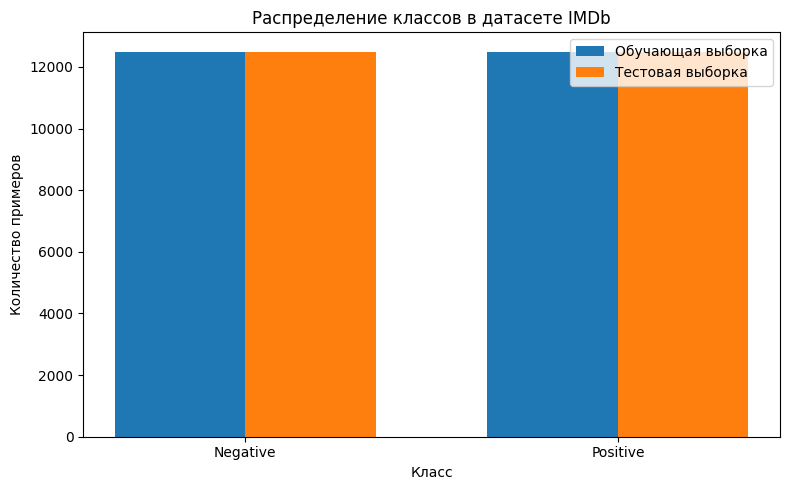


График распределения классов сохранён:
analysis_results/class_distribution.png

ВЫВОДЫ РАЗВЕДОЧНОГО АНАЛИЗА

1. Датасет содержит 50000 текстовых отзывов.

2. Датасет является сбалансированным:
   количество positive и negative отзывов одинаково.

3. Средняя длина отзывов составляет 234.76 слов.

4. Для ограничения вычислительной сложности
   длина последовательности ограничена значением MAX_LEN=200.

5. Использование ограничения словаря VOCAB_SIZE=10000
   позволяет уменьшить размерность входных данных
   и ускорить обучение моделей.

EDA-анализ завершён.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 10000
MAX_LEN = 200

os.makedirs("analysis_results", exist_ok=True)


print("=" * 60)
print("ЗАГРУЗКА ДАТАСЕТА IMDb")
print("=" * 60)

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Размер обучающей выборки: {len(x_train)}")
print(f"Размер тестовой выборки: {len(x_test)}")


print("\n" + "=" * 60)
print("РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 60)

train_lengths = [len(review) for review in x_train]
test_lengths = [len(review) for review in x_test]
all_lengths = train_lengths + test_lengths

print("\nАНАЛИЗ ДЛИН ОТЗЫВОВ")
print("-" * 40)

print(f"Количество отзывов: {len(all_lengths)}")
print(f"Минимальная длина: {np.min(all_lengths)} слов")
print(f"Максимальная длина: {np.max(all_lengths)} слов")
print(f"Средняя длина: {np.mean(all_lengths):.2f} слов")
print(f"Медианная длина: {np.median(all_lengths):.2f} слов")
print(f"Стандартное отклонение: {np.std(all_lengths):.2f}")

print("\nКВАНТИЛИ ДЛИНЫ ОТЗЫВОВ")
print("-" * 40)

for q in [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]:
    value = np.quantile(all_lengths, q)
    print(f"{int(q * 100)}% отзывов имеют длину <= {int(value)} слов")


plt.figure(figsize=(10, 6))

plt.hist(all_lengths, bins=50)

plt.title("Распределение длин текстовых отзывов")
plt.xlabel("Количество слов")
plt.ylabel("Количество отзывов")

plt.axvline(MAX_LEN, linestyle="--", label=f"MAX_LEN = {MAX_LEN}")

plt.legend()
plt.tight_layout()

plt.savefig("analysis_results/review_lengths_histogram.png")
plt.show()

print("\nГистограмма длин отзывов сохранена:")
print("analysis_results/review_lengths_histogram.png")


plt.figure(figsize=(10, 3))

sns.boxplot(x=all_lengths)

plt.title("Boxplot длин отзывов IMDb")
plt.xlabel("Количество слов")

plt.tight_layout()

plt.savefig("analysis_results/review_lengths_boxplot.png")
plt.show()

print("\nBoxplot длин отзывов сохранён:")
print("analysis_results/review_lengths_boxplot.png")


print("\n" + "=" * 60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ")
print("=" * 60)

train_positive = np.sum(y_train == 1)
train_negative = np.sum(y_train == 0)

test_positive = np.sum(y_test == 1)
test_negative = np.sum(y_test == 0)

print("\nОБУЧАЮЩАЯ ВЫБОРКА")
print("-" * 40)
print(f"Положительные отзывы (positive): {train_positive}")
print(f"Отрицательные отзывы (negative): {train_negative}")

print("\nТЕСТОВАЯ ВЫБОРКА")
print("-" * 40)
print(f"Положительные отзывы (positive): {test_positive}")
print(f"Отрицательные отзывы (negative): {test_negative}")

if train_positive == train_negative and test_positive == test_negative:
    print("\nДатасет является сбалансированным.")
    print("Выравнивание классов не требуется.")
else:
    print("\nОбнаружен дисбаланс классов.")


labels = ["Negative", "Positive"]
train_counts = [train_negative, train_positive]
test_counts = [test_negative, test_positive]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, train_counts, width, label="Обучающая выборка")
plt.bar(x + width/2, test_counts, width, label="Тестовая выборка")

plt.xticks(x, labels)

plt.title("Распределение классов в датасете IMDb")
plt.xlabel("Класс")
plt.ylabel("Количество примеров")

plt.legend()
plt.tight_layout()

plt.savefig("analysis_results/class_distribution.png")
plt.show()

print("\nГрафик распределения классов сохранён:")
print("analysis_results/class_distribution.png")


print("\n" + "=" * 60)
print("ВЫВОДЫ РАЗВЕДОЧНОГО АНАЛИЗА")
print("=" * 60)

print(
    f"""
1. Датасет содержит {len(all_lengths)} текстовых отзывов.

2. Датасет является сбалансированным:
   количество positive и negative отзывов одинаково.

3. Средняя длина отзывов составляет {np.mean(all_lengths):.2f} слов.

4. Для ограничения вычислительной сложности
   длина последовательности ограничена значением MAX_LEN={MAX_LEN}.

5. Использование ограничения словаря VOCAB_SIZE={VOCAB_SIZE}
   позволяет уменьшить размерность входных данных
   и ускорить обучение моделей.
"""
)

print("EDA-анализ завершён.")
